# Trabajo Práctico — Laboratorio de Programación en Python y R
### UTDT — Maestría en Econometría



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import optimize

sns.set_theme(style='whitegrid')
np.random.seed(42)

## Parte 1 — Robustez ante contaminación de muestras.

>



---
## 1.1 — Estimadores de tendencia central



Calculá el sesgo y el error cuadrático medio (ECM) empírico de la media y la mediana.





In [2]:
def sesgo_empirico(estimaciones, valor_verdadero):
    """Sesgo empirico: promedio de las estimaciones menos el valor verdadero."""
    return np.mean(estimaciones) - valor_verdadero

def ecm_empirico(estimaciones, valor_verdadero):
    """Error cuadratico medio empirico respecto al valor verdadero."""
    return np.mean((estimaciones - valor_verdadero) ** 2)

def generar_muestra_contaminada(n, p, mu0, sigma0, mu1, sigma1, rng):
    """Genera una muestra de tamano n de N(mu0, sigma0^2), contaminando
    una proporcion p de las observaciones con outliers N(mu1, sigma1^2)."""
    muestra = rng.normal(mu0, sigma0, size=n)
    n_outliers = int(round(n * p))
    if n_outliers > 0:
        idx_outliers = rng.choice(n, size=n_outliers, replace=False)
        muestra[idx_outliers] = rng.normal(mu1, sigma1, size=n_outliers)
    return muestra

### Diseño de la simulación

Para cada nivel de contaminación p, generamos M = 1000 simulaciones, muestras independientes de tamaño n = 200. En cada una, calculamos la media y la mediana. Al final tenemos M estimaciones de cada estadístico por cada p, permitiendo calcular el sesgo y el ECM empírico.

In [3]:
# Parametros del ejercicio
mu0, sigma0 = 0.0, 1.0      # distribucion "limpia"
mu1, sigma1 = 8.0, 5.0      # distribucion de los outliers (bien separada y mas dispersa)
n = 200                      # tamano de cada muestra
M = 1000                     # simulaciones por nivel de contaminacion
niveles_p = [0.00, 0.05, 0.10, 0.20]

rng = np.random.default_rng(123)

resultados_1_1 = []
for p in niveles_p:
    medias = np.empty(M)
    medianas = np.empty(M)
    for m in range(M):
        muestra = generar_muestra_contaminada(n, p, mu0, sigma0, mu1, sigma1, rng)
        medias[m] = np.mean(muestra)
        medianas[m] = np.median(muestra)
    resultados_1_1.append({
        'p': p,
        'sesgo_media': sesgo_empirico(medias, mu0),
        'ecm_media': ecm_empirico(medias, mu0),
        'sesgo_mediana': sesgo_empirico(medianas, mu0),
        'ecm_mediana': ecm_empirico(medianas, mu0),
    })

tabla_1_1 = pd.DataFrame(resultados_1_1)
tabla_1_1

,p,sesgo_media,ecm_media,sesgo_mediana,ecm_mediana
0,0.00,-0.001348,0.004874,-0.004191,0.007496
1,0.05,0.402349,0.173416,0.063655,0.012435
2,0.10,0.794506,0.648502,0.124405,0.023997
3,0.20,1.600610,2.589581,0.282855,0.091102


### ¿A partir de qué nivel de contaminación gana la mediana en ECM?

Buscamos el primer nivel de p simulado en el que el ECM de la mediana es menor que el de la media.

In [4]:
cruce = tabla_1_1[tabla_1_1['ecm_mediana'] < tabla_1_1['ecm_media']]
if len(cruce) > 0:
    p_cruce = cruce['p'].iloc[0]
    print(f'La mediana empieza a ganar en ECM a partir de p = {p_cruce:.0%} de contaminacion.')
else:
    print('En el rango de p simulado, la media siempre tiene menor ECM.')

tabla_1_1[['p', 'ecm_media', 'ecm_mediana']]

La mediana empieza a ganar en ECM a partir de p = 5% de contaminacion.


,p,ecm_media,ecm_mediana
0,0.00,0.004874,0.007496
1,0.05,0.173416,0.012435
2,0.10,0.648502,0.023997
3,0.20,2.589581,0.091102


### Gráfico de lineas.



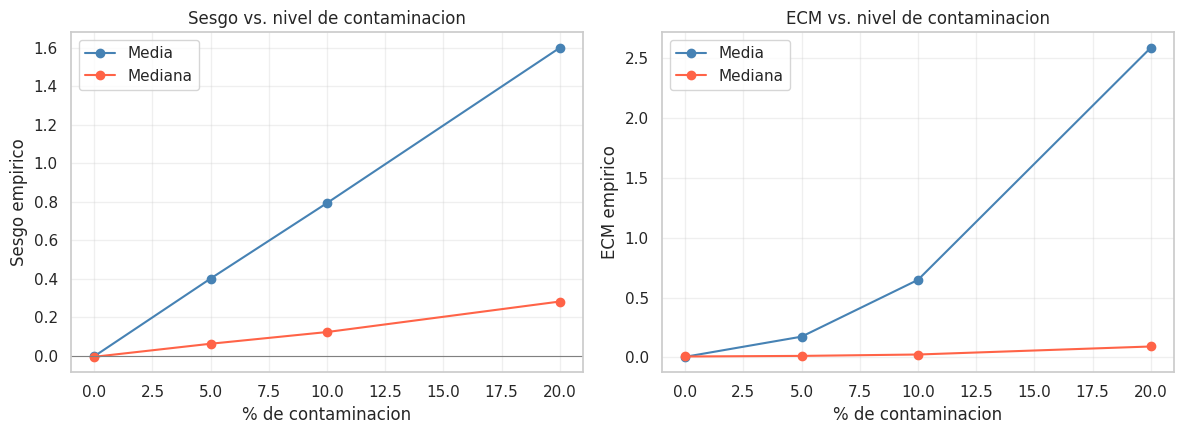

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(tabla_1_1['p']*100, tabla_1_1['sesgo_media'], marker='o', color='steelblue', label='Media')
axes[0].plot(tabla_1_1['p']*100, tabla_1_1['sesgo_mediana'], marker='o', color='tomato', label='Mediana')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('% de contaminacion')
axes[0].set_ylabel('Sesgo empirico')
axes[0].set_title('Sesgo vs. nivel de contaminacion')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tabla_1_1['p']*100, tabla_1_1['ecm_media'], marker='o', color='steelblue', label='Media')
axes[1].plot(tabla_1_1['p']*100, tabla_1_1['ecm_mediana'], marker='o', color='tomato', label='Mediana')
axes[1].set_xlabel('% de contaminacion')
axes[1].set_ylabel('ECM empirico')
axes[1].set_title('ECM vs. nivel de contaminacion')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Cuando p = 0 no muestra contaminación la media es más eficiente, es decir presenta un menor ECM y por ende es más eficiente que la mediana, como lo expresa el supuestode normalidad, donde la media es el estimador de máxima verosimilitud. Sucede que a medida que crece la contaminación, la media se ve más afectada por los outliers (valores atípicos) ya que estos datos estan muy alejados y por tanto mucho más dispersos. En contraste, la mediana depende del orden de las observaciones y no de la magnitud de los valores extremos. Por eso el ECM de la mediana crece mucho más lentamente con p, por este motivo la mediana termina presentando un menor EMC y por tanto mejor desempeño en términos de precisión.

---
## Parte 1.2 — Regresión lineal bajo contaminación

Comparamos **OLS** (implementado a mano, matricialmente) y **LAD** (Least Absolute Deviations, minimizado con scipy.optimize.minimize) bajo el mismo esquema de contaminación.

In [6]:
def calcular_beta_ols(X, y):
    """Estimador OLS via la formula matricial beta = (X'X)^-1 X'y.
    Prohibido usar statsmodels o sklearn para este estimador."""
    return np.linalg.solve(X.T @ X, X.T @ y)

def estimar_lad(X, y, beta_init=None):
    """Estimador LAD: minimiza la suma de valores absolutos de los residuos
    con scipy.optimize.minimize (metodo Nelder-Mead), tal como se vio en el
    laboratorio de funciones de costo y regresion robusta."""
    if beta_init is None:
        beta_init = calcular_beta_ols(X, y)  # arrancamos desde OLS

    def objetivo(beta):
        residuos = y - X @ beta
        return np.sum(np.abs(residuos))

    resultado = optimize.minimize(
        objetivo, beta_init, method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8}
    )
    return resultado.x

In [7]:
def generar_datos_regresion_contaminada(n, p, beta0, beta1, sigma_eps,
                                         mu1, sigma1, rng):
    """Genera datos de y = beta0 + beta1*x + eps, contaminando una
    proporcion p de las observaciones (en x e y) con outliers severos."""
    x = rng.uniform(0, 10, size=n)
    eps = rng.normal(0, sigma_eps, size=n)
    y = beta0 + beta1 * x + eps

    n_outliers = int(round(n * p))
    if n_outliers > 0:
        idx_outliers = rng.choice(n, size=n_outliers, replace=False)
        y[idx_outliers] += rng.normal(mu1, sigma1, size=n_outliers)
        x[idx_outliers] += rng.normal(mu1, sigma1, size=n_outliers)

    X = np.column_stack([np.ones(n), x])
    return X, y

### Diseño de la simulación

Ahora se simulan datos de regresión: para cada nivel de contaminación p genera M = 500 muestras de tamaño n = 200, contaminando tanto x como y con outliers severos (para que también distorsionen el apalancamiento, no solo el nivel de y). En cada muestra se estiman $\hat\beta_1$ por OLS y por LAD, y con las M estimaciones de cada método calculamos sesgo y ECM.

In [8]:
# Parametros del ejercicio
beta0_true, beta1_true = 2.0, 3.0
sigma_eps = 1.5
n_reg = 200
M_reg = 500
mu1_reg, sigma1_reg = 20.0, 5.0   # outliers bien separados
niveles_p_reg = [0.00, 0.05, 0.10, 0.20]

rng = np.random.default_rng(456)

resultados_1_2 = []
for p in niveles_p_reg:
    betas1_ols = np.empty(M_reg)
    betas1_lad = np.empty(M_reg)
    for m in range(M_reg):
        X, y = generar_datos_regresion_contaminada(
            n_reg, p, beta0_true, beta1_true, sigma_eps, mu1_reg, sigma1_reg, rng
        )
        betas1_ols[m] = calcular_beta_ols(X, y)[1]
        betas1_lad[m] = estimar_lad(X, y)[1]
    resultados_1_2.append({
        'p': p,
        'sesgo_ols': sesgo_empirico(betas1_ols, beta1_true),
        'ecm_ols': ecm_empirico(betas1_ols, beta1_true),
        'sesgo_lad': sesgo_empirico(betas1_lad, beta1_true),
        'ecm_lad': ecm_empirico(betas1_lad, beta1_true),
    })

tabla_1_2 = pd.DataFrame(resultados_1_2)
tabla_1_2

,p,sesgo_ols,ecm_ols,sesgo_lad,ecm_lad
0,0.00,-0.000645,0.001500,-0.000548,0.002333
1,0.05,-1.457292,2.142371,-0.258440,0.070419
2,0.10,-1.689594,2.864741,-0.879746,0.838386
3,0.20,-1.847373,3.417919,-1.687109,2.857863


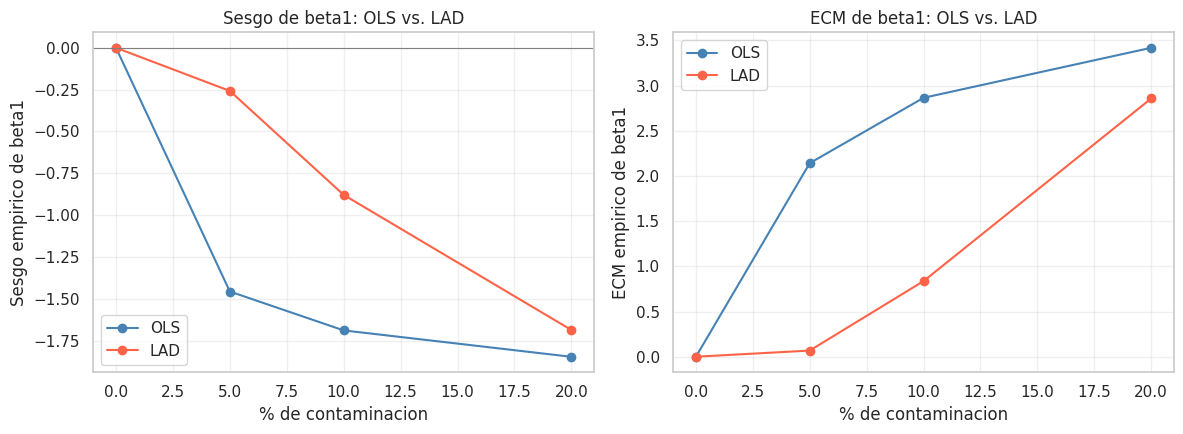

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(tabla_1_2['p']*100, tabla_1_2['sesgo_ols'], marker='o', color='steelblue', label='OLS')
axes[0].plot(tabla_1_2['p']*100, tabla_1_2['sesgo_lad'], marker='o', color='tomato', label='LAD')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xlabel('% de contaminacion')
axes[0].set_ylabel('Sesgo empirico de beta1')
axes[0].set_title('Sesgo de beta1: OLS vs. LAD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(tabla_1_2['p']*100, tabla_1_2['ecm_ols'], marker='o', color='steelblue', label='OLS')
axes[1].plot(tabla_1_2['p']*100, tabla_1_2['ecm_lad'], marker='o', color='tomato', label='LAD')
axes[1].set_xlabel('% de contaminacion')
axes[1].set_ylabel('ECM empirico de beta1')
axes[1].set_title('ECM de beta1: OLS vs. LAD')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** en p = 0 (en asusencia de contaminación), OLS es más eficiente (menor ECM) que LAD (Least Absolute Deviations), consistente con ser el estimador de máxima verosimilitud bajo errores normales. Al incrementarse la contaminación, OLS se degrada rápido en respuesta a que la función de costo cuadrática penaliza muchísimo los residuos grandes que generan los outliers (la contaminación afecta tanto a x como a y, las observaciones atípicas pueden generar problemas de apalancamiento y ejercer una influencia sobre las estimaciones). En cambio, LAD, al minimizar la suma de valores absolutos, es más sensible a las observaciones extremas y por lo tanto muestra un comportameinto mucho más robusto frente a la contaminación, mantiendo el sesgo y el ECM acotados incluso con niveles de contaminación altos.

---
## Parte 2 — Paradoja de Simpson y variables omitidas

### 2.1 — Construcción del modelo

Se simula $X \sim N(0,1)$ y dos variables discretas $Z, W \in \{1,2,3,4\}$, cada una correlacionada con $X$ pero **no correlacionadas entre sí**. El modelo verdadero es $Y = \beta_Z Z + \beta_W W + \varepsilon$ — **$X$ no tiene ningún efecto directo sobre $Y$**. Todo el vínculo aparente entre $X$ e $Y$ viene exclusivamente del sesgo por variable omitida.

Con $\beta_Z = -1$, $\beta_W = +1$, $\text{corr}(X,Z) = \text{corr}(X,W) = -0{,}5$ y $\text{corr}(Z,W)=0$, se puede demostrar (y verificar por simulación) que:
- El sesgo por omitir $Z$ y el sesgo por omitir $W$ en la regresión marginal se **cancelan exactamente**, dando un coeficiente nulo.
- Al controlar por $Z$ (y omitir $W$) queda el sesgo de $W$ solo, que es **negativo**.
- Al controlar por $W$ (y omitir $Z$) queda el sesgo de $Z$ solo, que es **positivo**.

In [10]:
def simular_datos_simpson(n, rng):
    """Genera X, Z, W, Y segun el diseno causal de la Parte 2."""
    rho_xz, rho_xw, rho_zw = -0.5, -0.5, 0.0
    Sigma = np.array([[1, rho_xz, rho_xw],
                       [rho_xz, 1, rho_zw],
                       [rho_xw, rho_zw, 1]])
    datos = rng.multivariate_normal([0, 0, 0], Sigma, size=n)
    X, Zc, Wc = datos[:, 0], datos[:, 1], datos[:, 2]

    # Discretizamos Z y W en cuartiles -> 4 niveles (1 a 4)
    Z = np.digitize(Zc, bins=np.quantile(Zc, [0.25, 0.5, 0.75])) + 1
    W = np.digitize(Wc, bins=np.quantile(Wc, [0.25, 0.5, 0.75])) + 1

    beta_z, beta_w = -1.0, 1.0
    Y = beta_z * Z + beta_w * W + rng.normal(0, 1, size=n)
    return X, Z, W, Y

# Chequeo rapido con una muestra grande
rng_check = np.random.default_rng(1)
X, Z, W, Y = simular_datos_simpson(50_000, rng_check)

m_marginal = sm.OLS(Y, sm.add_constant(X)).fit()
m_conZ = sm.OLS(Y, sm.add_constant(np.column_stack([X, Z]))).fit()
m_conW = sm.OLS(Y, sm.add_constant(np.column_stack([X, W]))).fit()

print(f'Y ~ X          : beta_X = {m_marginal.params[1]:.4f}  (p={m_marginal.pvalues[1]:.3f})')
print(f'Y ~ X + Z      : beta_X = {m_conZ.params[1]:.4f}')
print(f'Y ~ X + W      : beta_X = {m_conW.params[1]:.4f}')

Y ~ X          : beta_X = 0.0064  (p=0.443)
Y ~ X + Z      : beta_X = -0.6540
Y ~ X + W      : beta_X = 0.6505


### 2.2 — Distribución de $\hat\beta_X$ bajo las tres especificaciones (M = 1000)

Uso de statsmodels permitido explícitamente en esta parte del enunciado.

Se repite la simulación M = 1000 veces (cada una con n = 300 observaciones nuevas) y se guarda en cada repetición, el $\hat\beta_X$ de las tres especificaciones. Esto da, para cada especificación, una distribución empírica de $\hat\beta_X$ en vez de una sola estimación puntual — así se puede ver no solo el valor esperado (relacionado con el sesgo) sino también la dispersión (relacionada con la varianza) de cada estimador.

In [11]:
M_simpson = 1000
n_simpson = 300
rng = np.random.default_rng(789)

betas_sin_control = np.empty(M_simpson)
betas_con_Z = np.empty(M_simpson)
betas_con_W = np.empty(M_simpson)

for m in range(M_simpson):
    X, Z, W, Y = simular_datos_simpson(n_simpson, rng)
    betas_sin_control[m] = sm.OLS(Y, sm.add_constant(X)).fit().params[1]
    betas_con_Z[m] = sm.OLS(Y, sm.add_constant(np.column_stack([X, Z]))).fit().params[1]
    betas_con_W[m] = sm.OLS(Y, sm.add_constant(np.column_stack([X, W]))).fit().params[1]

resumen_simpson = pd.DataFrame({
    'especificacion': ['Y ~ X (sin controles)', 'Y ~ X + Z', 'Y ~ X + W'],
    'beta_X promedio': [betas_sin_control.mean(), betas_con_Z.mean(), betas_con_W.mean()],
    'desvio': [betas_sin_control.std(), betas_con_Z.std(), betas_con_W.std()],
})
resumen_simpson

,especificacion,beta_X promedio,desvio
0,Y ~ X (sin controles),-0.003036,0.096107
1,Y ~ X + Z,-0.658621,0.081139
2,Y ~ X + W,0.654017,0.082939


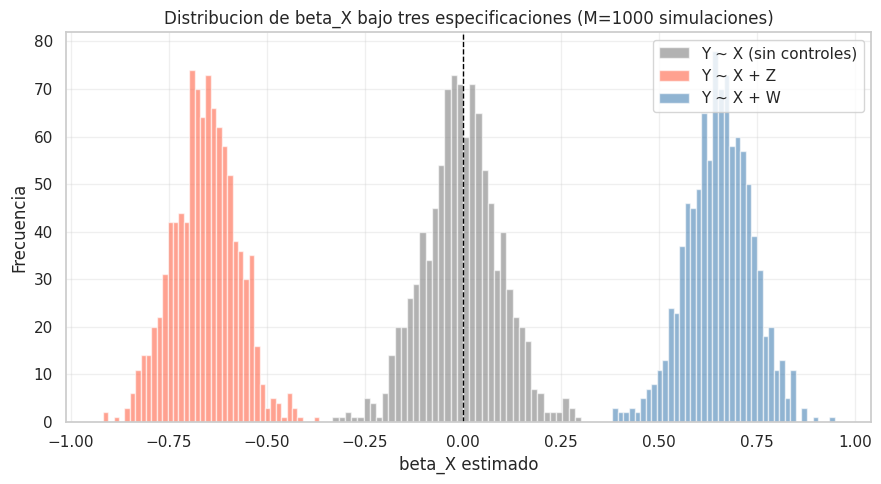

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(betas_sin_control, bins=40, alpha=0.6, color='gray', label='Y ~ X (sin controles)')
ax.hist(betas_con_Z, bins=40, alpha=0.6, color='tomato', label='Y ~ X + Z')
ax.hist(betas_con_W, bins=40, alpha=0.6, color='steelblue', label='Y ~ X + W')
ax.axvline(0, color='black', linestyle='--', linewidth=1)

ax.set_xlabel('beta_X estimado')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribucion de beta_X bajo tres especificaciones (M={M_simpson} simulaciones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** el verdadero efecto de $X$ sobre $Y$ es igual a cero en las tres especificaciones — por que así fue construido el modelo. Sin embargo, como $X$ está correlacionada con las dos variables omitidas (confusoras), genera un sesgo por variable omitida esto hace que el coeficiente estimado de $X$ sea sistemáticamente distinto de cero. Salvo cuando ambas fuentes de sesgo están presentes simultáneamente y se cancelan (regresión marginal). Al aumentar $M$ o el tamaño de muestra n se reduce la **variabilidad** de $\hat\beta_X$ en torno a su valor esperado, pero **no corrige el sesgo**: Por esta razón las tres distribuciones siguen centradas en sus respectivos valores sesgados (0, negativo, positivo) independientemente de cuántas observaciones o simulaciones se agreguen. El sesgo por variable omitida es un problema de identificación, no de tamaño de muestra.

---
## Parte 3 — Análisis empiríco con Gapminder

Se escoge a Honduras y se responden las dos preguntas: Convergencia y Atipicidad con las visualizaciones que se consideran más claras.



Cargamos el dataset y calculamos, para cada año, el promedio mundial de esperanza de vida y PBI per cápita — esa serie de promedios es la vara con la que comparamos al país elegido en ambas preguntas.

In [13]:
url_gapminder = 'https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv'
gapminder = pd.read_csv(url_gapminder)

pais_elegido = 'Honduras'   # <-- reemplazar por el pais del grupo
continente = gapminder.loc[gapminder['country'] == pais_elegido, 'continent'].iloc[0]

gapminder.head()

,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


### Pregunta 1 — ¿El país converge hacia el promedio mundial (1952-2007)?

Se compara la evolución de la esperanza de vida y del PBI per cápita del país elegido contra el promedio mundial de cada año, para ver si la brecha se achica con el tiempo.

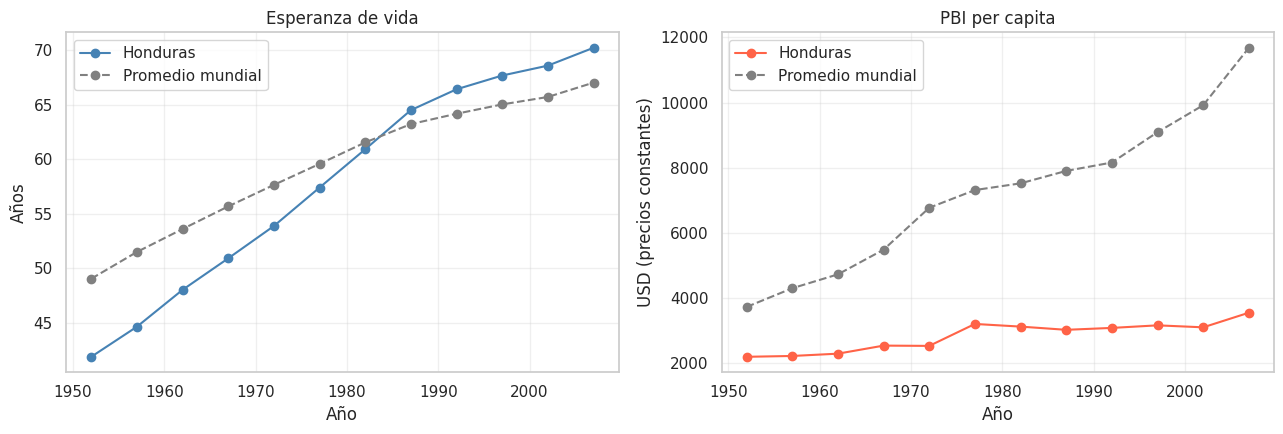

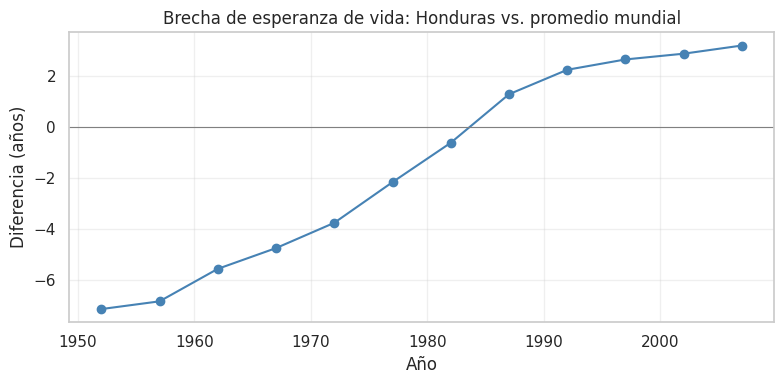

In [14]:
promedio_mundial = gapminder.groupby('year')[['lifeExp', 'gdpPercap']].mean().reset_index()
serie_pais = gapminder[gapminder['country'] == pais_elegido].sort_values('year')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(serie_pais['year'], serie_pais['lifeExp'], marker='o', color='steelblue', label=pais_elegido)
axes[0].plot(promedio_mundial['year'], promedio_mundial['lifeExp'], marker='o', color='gray',
             linestyle='--', label='Promedio mundial')
axes[0].set_title('Esperanza de vida')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Años')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(serie_pais['year'], serie_pais['gdpPercap'], marker='o', color='tomato', label=pais_elegido)
axes[1].plot(promedio_mundial['year'], promedio_mundial['gdpPercap'], marker='o', color='gray',
             linestyle='--', label='Promedio mundial')
axes[1].set_title('PBI per capita')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('USD (precios constantes)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Brecha respecto al promedio mundial a lo largo del tiempo
brecha = serie_pais.merge(promedio_mundial, on='year', suffixes=('_pais', '_mundial'))
brecha['brecha_lifeExp'] = brecha['lifeExp_pais'] - brecha['lifeExp_mundial']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(brecha['year'], brecha['brecha_lifeExp'], marker='o', color='steelblue')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title(f'Brecha de esperanza de vida: {pais_elegido} vs. promedio mundial')
ax.set_xlabel('Año')
ax.set_ylabel('Diferencia (años)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Pregunta 1 - ¿Convergió Honduras hacia el promedio mundial en esperanza de vida entre 1952 y 2007, o la brecha se mantuvo?





**Análisis de Honduras**

Honduras muestra una dinámica dual entre 1952 y 2007. En la **Esperanza de vida** hay convergencia clara: la brecha con respecto al promedio mundial pasa de -7.0 años en 1950 a +2/+3 años en 2007, cruzando el cero cerca de 1983, Honduras termina superando el promedio mundial en este indicador. En el PIB per cápita, en cambio, el patrón es de divergencia: Honduras comienza en USD2000, mientras el promedio mundial aunque es bajo USD4000, este se acelera fuertemente desde la decada de los 90 llegando a USD12000 en 2007, el ingreso percapita hondureño permanece prácticamente estancado entre los USD4000 a 5000, ampliandose la brecha en términos absolutos.

### Pregunta 2 — ¿Es un país atípico dentro de su continente?

Comparamos al país elegido contra la distribución de todos los países del mismo continente en el último año disponible (2007), usando un boxplot para ubicarlo dentro de la distribución.

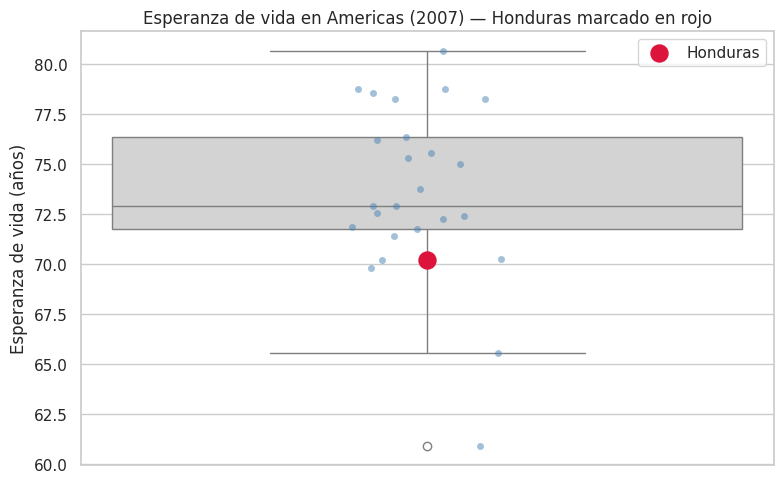

Honduras esta en el percentil 12 de esperanza de vida dentro de Americas (2007).


In [15]:
datos_2007 = gapminder[gapminder['year'] == 2007]
datos_continente = datos_2007[datos_2007['continent'] == continente]
valor_pais = datos_2007.loc[datos_2007['country'] == pais_elegido, 'lifeExp'].iloc[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=datos_continente, y='lifeExp', color='lightgray', ax=ax)
sns.stripplot(data=datos_continente, y='lifeExp', color='steelblue', alpha=0.5, ax=ax)
ax.scatter([0], [valor_pais], color='crimson', s=150, zorder=5, label=pais_elegido)
ax.set_title(f'Esperanza de vida en {continente} (2007) — {pais_elegido} marcado en rojo')
ax.set_ylabel('Esperanza de vida (años)')
ax.legend()
plt.tight_layout()
plt.show()

percentil = (datos_continente['lifeExp'] < valor_pais).mean() * 100
print(f'{pais_elegido} esta en el percentil {percentil:.0f} de esperanza de vida dentro de {continente} (2007).')

**Esperanza de vida de Honduras 2007**

En 2007, Honduras se ubicó en el percentil 12 de **Esperanza de vida** dentro de América, claramente por debajo del rango intercuartilico del continente (72-75 años vs 70 años de Honduras). Sin embargo, no constituye un valor atípico extremo según el criterio de los bigotes de boxplot (al menos un país de la región marcado como circulo abierto en el gráfico) presenta una esperanza de vida aún menor.


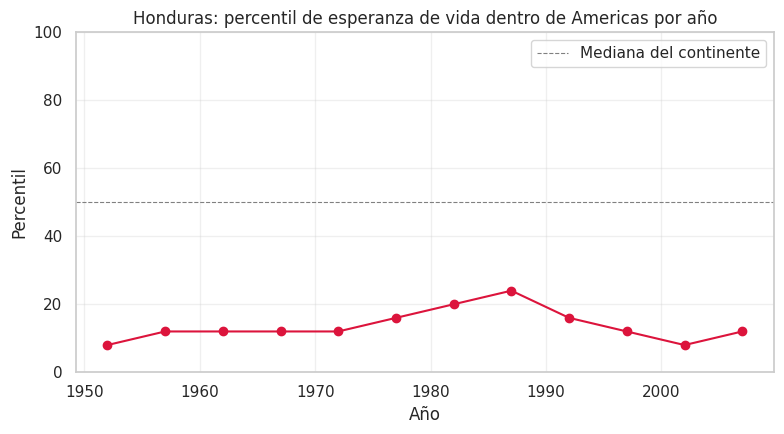

Peor percentil relativo: año 1952, percentil 8


,year,percentil,lifeExp
0,1952,8.0,41.912
1,1957,12.0,44.665
2,1962,12.0,48.041
3,1967,12.0,50.924
4,1972,12.0,53.884
5,1977,16.0,57.402
6,1982,20.0,60.909
7,1987,24.0,64.492
8,1992,16.0,66.399
9,1997,12.0,67.659


In [16]:
percentiles_por_anio = []
for anio in sorted(gapminder['year'].unique()):
    datos_anio = gapminder[gapminder['year'] == anio]
    datos_cont_anio = datos_anio[datos_anio['continent'] == continente]
    valor_pais_anio = datos_anio.loc[datos_anio['country'] == pais_elegido, 'lifeExp'].iloc[0]
    pct = (datos_cont_anio['lifeExp'] < valor_pais_anio).mean() * 100
    percentiles_por_anio.append({'year': anio, 'percentil': pct, 'lifeExp': valor_pais_anio})

tabla_percentiles = pd.DataFrame(percentiles_por_anio)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tabla_percentiles['year'], tabla_percentiles['percentil'], marker='o', color='crimson')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='Mediana del continente')
ax.set_title(f'{pais_elegido}: percentil de esperanza de vida dentro de {continente} por año')
ax.set_xlabel('Año')
ax.set_ylabel('Percentil')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

anio_min = tabla_percentiles.loc[tabla_percentiles['percentil'].idxmin()]
print(f"Peor percentil relativo: año {int(anio_min['year'])}, percentil {anio_min['percentil']:.0f}")
tabla_percentiles

### Esperanza de vida de Honduras en el período 1952-2007

Honduras nunca superó el percentil 24 de Esperanza de vida dentro de América en el período 1952-2007, permaneciendo en el cuartil inferior del continente. Se observa una mejora relativa entre 1952 (percentil 8) y 1987 (percentil 24), seguida de un deterioro sostenido que lo devuelve al percentil 8 en 2002 empatando el peor valor de toda la serie. Esto coincide con el paso del Huracán Mitch, uno de los desastres naturales más desvastadores en la historia de Honduras, causando muertes y pérdidas económicas equivalentes al PIB del país, retrasando su desarrollo relativo frente al resto de países del continente. A pesar de lo anterior la esperanza de vida no dejo de crecer, el país mejoró en términos absolutos al mismo ritmo o más lento que sus vecinos, por lo que su posición relativa dentro de América se estancó en vez de mejorar.